In [1]:
import time
import math
import matplotlib.pyplot as plt
from dds import DDS

In [2]:
class PID_Controller:
    def __init__(self, kp, ki, kd):
        self.kp = kp
        self.ki = ki
        self.kd = kd
        self.integral = 0.0
        self.prev_error = 0.0

    # Aggiungiamo max_output come parametro opzionale
    def evaluate(self, error, dt, max_output=None):
        p = self.kp * error
        
        if dt > 0.0:
            d = self.kd * (error - self.prev_error) / dt
        else:
            d = 0.0

        if max_output is not None:
            potential_output = p + (self.ki * self.integral) + d
            
            is_saturated = abs(potential_output) >= max_output
            
            same_direction = (potential_output > 0 and error > 0) or (potential_output < 0 and error < 0)
            
            if is_saturated and same_direction:
                pass 
            else:
                self.integral += error * dt
        else:
            self.integral += error * dt

        i = self.ki * self.integral
        self.prev_error = error

        final_output = p + i + d

        if max_output is not None:
            final_output = max(-max_output, min(max_output, final_output))

        return final_output

In [ ]:
dds = DDS()
dds.start('127.0.0.1', 4444)
dds.subscribe(['tick', 'X', 'Z', 'Yaw', 'Speed', 'X_dest', 'Z_dest', 'Robot_index', 'Trajectory_Type'])


acceptance_radius = 2
slow_radius = 5


max_speed = 3
target_speed = 3
max_torque = 150

speed_pid = PID_Controller(20.0, 100.0, 0.05)
steering_pid = PID_Controller(kp=1.0, ki=0.0, kd=0.0)

max_steering = 35


d_x = []
d_z = []   
d_time = []
d_target_speed = []
d_current_speed = []
d_angle_error = []
d_steering = []

print("Starting robot conrtrol...")
start_time = time.time()

try:
    while True:
        delta_t = dds.wait('tick')
        if delta_t is None:
            continue
            
        t_elapsed = time.time() - start_time
        
        

        x = dds.read('X')
        z = dds.read('Z')
        yaw = dds.read('Yaw') 
        current_speed = dds.read('Speed')
        target_x = dds.read('X_dest')
        target_z = dds.read('Z_dest')
        Robot_index = dds.read('Robot_index')
        Trajectory_Type = dds.read('Trajectory_Type')

        if None in (x, z, yaw, current_speed, target_x, target_z, Robot_index, Trajectory_Type):
            print('error')
            continue


        if target_x == -999:
            print('Path finished! Terminating.')
            dds.publish('Torque', 0, DDS.DDS_TYPE_FLOAT)
            dds.publish('Theta', 0, DDS.DDS_TYPE_FLOAT)
            break

        yaw_deg = math.degrees(yaw)
        dist_to_target = math.hypot(target_x - x, target_z - z)
        target_angle = math.atan2(target_x - x, target_z - z)
        target_angle = math.degrees(target_angle)
        angle_error = target_angle - yaw_deg

        if dist_to_target < slow_radius:
            if Trajectory_Type == 1:
                target_speed = max(2.3, target_speed - 0.05)
            if Trajectory_Type == 2:
                target_speed = max(0.5, target_speed - 0.05)
        else:
            target_speed = min(max_speed, target_speed + 0.03)
        

        if dist_to_target < acceptance_radius:
            print(f'Waypoint {Robot_index + 1} reached! ({target_x}, {target_z})')
            Robot_index += 1
            
            dds.publish('Control_Index', Robot_index, DDS.DDS_TYPE_INT)
            
        angle_error = (angle_error + 180) % 360 - 180
        raw_steering = steering_pid.evaluate(angle_error, delta_t)
        target_steering = max(-max_steering, min(max_steering, raw_steering))

        speed_error = target_speed - current_speed
        torque = speed_pid.evaluate(speed_error, delta_t, max_torque)




        # Invio dati a Godot
        dds.publish('Torque', torque, DDS.DDS_TYPE_FLOAT)
        dds.publish('Theta', target_steering, DDS.DDS_TYPE_FLOAT)

        d_time.append(t_elapsed)
        d_x.append(x)
        d_z.append(z)
        d_target_speed.append(target_speed)
        d_current_speed.append(current_speed)
        d_angle_error.append(angle_error)
        d_steering.append(target_steering)

except KeyboardInterrupt:
    print('interrotto')

Starting robot conrtrol...
error
Waypoint 1 reached! (0.0, 0.0)
Waypoint 1 reached! (0.0, 0.0)
Waypoint 2 reached! (0.0, 10.0)
Waypoint 2 reached! (0.0, 10.0)
Waypoint 3 reached! (0.0, 20.0)
Waypoint 3 reached! (0.0, 20.0)
Waypoint 4 reached! (10.0, 20.0)
Waypoint 4 reached! (10.0, 20.0)
Waypoint 5 reached! (20.0, 20.0)
Waypoint 5 reached! (20.0, 20.0)
Waypoint 6 reached! (20.0, 30.0)
Waypoint 6 reached! (20.0, 30.0)
Waypoint 7 reached! (30.0, 30.0)
Waypoint 7 reached! (30.0, 30.0)
Path finished! Terminating.


/var/folders/4t/nmbjvjh562g4667lvlkmt6z80000gn/T/ipykernel_68351/3316728890.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


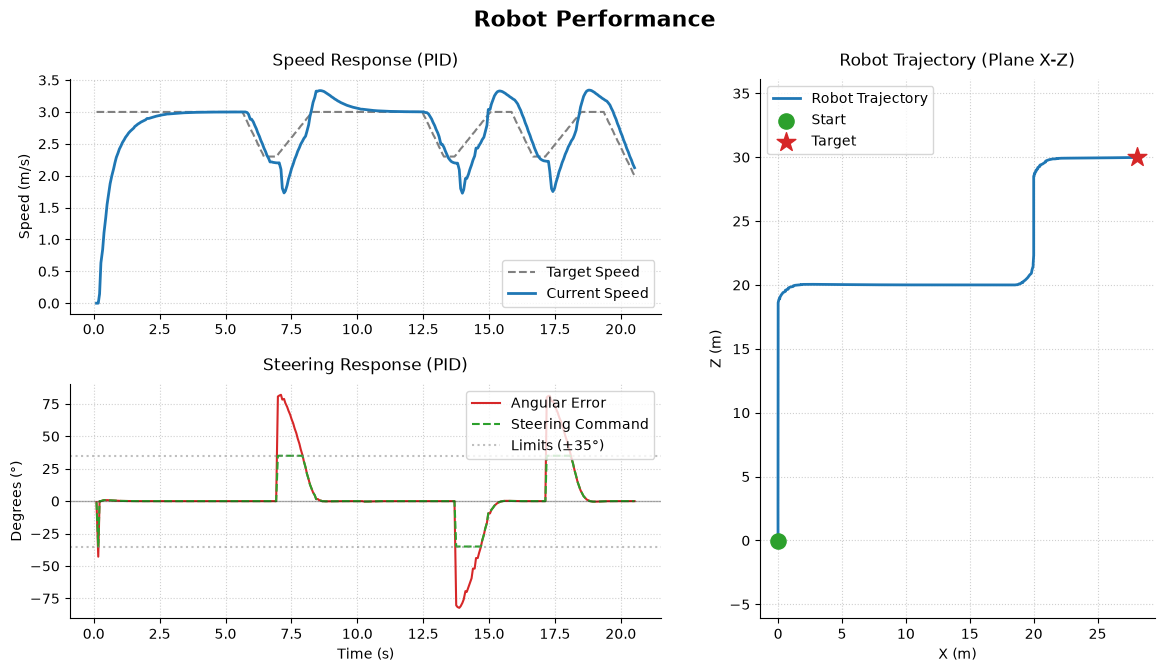

In [35]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(14, 7))
fig.suptitle("Robot Performance", fontsize=16, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(2, 2, width_ratios=[1.5, 1], hspace=0.3, wspace=0.2)


ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(d_time, d_target_speed, label="Target Speed", linestyle='--', color='gray', linewidth=1.5)
ax1.plot(d_time, d_current_speed, label="Current Speed", color='#1f77b4', linewidth=2)
ax1.set_title("Speed Response (PID)", fontsize=12, pad=10)
ax1.set_ylabel("Speed (m/s)")
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='lower right')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)


ax2 = fig.add_subplot(gs[1, 0], sharex=ax1) 
ax2.plot(d_time, d_angle_error, label="Angular Error", color='#d62728', linewidth=1.5)
ax2.plot(d_time, d_steering, label="Steering Command", color='#2ca02c', linestyle='--', linewidth=1.5)
ax2.axhline(y=35, color='gray', linestyle=':', alpha=0.5, label="Limits (±35°)")
ax2.axhline(y=-35, color='gray', linestyle=':', alpha=0.5)
ax2.axhline(y=0, color='black', linewidth=1, alpha=0.3) 
ax2.set_title("Steering Response (PID)", fontsize=12, pad=10)
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Degrees (°)")
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(loc='upper right')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)


ax3 = fig.add_subplot(gs[:, 1]) 
ax3.plot(d_x, d_z, label="Robot Trajectory", color='#1f77b4', linewidth=2)
ax3.scatter([d_x[0]], [d_z[0]], color='#2ca02c', marker='o', s=120, label="Start", zorder=5)
ax3.scatter([d_x[-1]], [d_z[-1]], color='#d62728', marker='*', s=200, label="Target", zorder=5)
ax3.set_title("Robot Trajectory (Plane X-Z)", fontsize=12, pad=10)
ax3.set_xlabel("X (m)")
ax3.set_ylabel("Z (m)")
ax3.axis('equal') 
ax3.grid(True, linestyle=':', alpha=0.6)
ax3.legend(loc='upper left')
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)


plt.tight_layout() 
plt.subplots_adjust(top=0.88) 
plt.show()